### What this notebook does
1. Load the processed dataset from Notebook 3
2. Benchmark multiple models with cross-validation
3. Train the final Random Forest model
4. Evaluate on the held-out validation set
5. Feature importance analysis
6. Anomaly scoring with Isolation Forest
7. Save the model and scaler for deployment

## Imports & Configuration

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("husl")

SEED        = 42
DATA_DIR    = "data"
MODELS_DIR  = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Setup complete")

Setup complete


## Load Processed Data

In [2]:
train_path = os.path.join(DATA_DIR, "processed", "train_processed.csv")
df = pd.read_csv(train_path)

TARGET_COL = "attack_class"
X = df.drop(columns=[TARGET_COL]).fillna(0)
y = df[TARGET_COL]

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nClass distribution:")
print(y.value_counts())

Dataset shape : 336,715 rows × 54 columns

Class distribution:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


## Model Benchmarking with Cross-Validation

We compare Logistic Regression and Random Forest using 5-fold stratified CV.

In [3]:
MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=SEED
    ),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

rows = []
for name, model in MODELS.items():
    print(f"  Training {name} …")
    scores = cross_validate(model, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    rows.append({
        "Model":     name,
        "Accuracy":  scores["test_accuracy"].mean(),
        "F1 Macro":  scores["test_f1_macro"].mean(),
        "Precision": scores["test_precision_macro"].mean(),
        "Recall":    scores["test_recall_macro"].mean(),
    })

benchmark = pd.DataFrame(rows).sort_values("F1 Macro", ascending=False)
print("\n" + "─" * 60)
print("Cross-Validation Benchmark Results (5-fold, macro avg)")
print("─" * 60)
benchmark.style.background_gradient(cmap="YlGn", subset=["Accuracy", "F1 Macro", "Precision", "Recall"])

  Training Logistic Regression …
  Training Random Forest …

────────────────────────────────────────────────────────────
Cross-Validation Benchmark Results (5-fold, macro avg)
────────────────────────────────────────────────────────────


,Model,Accuracy,F1 Macro,Precision,Recall
1,Random Forest,0.999721,0.999721,0.999721,0.999721
0,Logistic Regression,0.808330,0.806333,0.824150,0.808331


## Train Final Model

Random Forest is our best model. We train it on 80% of the data and evaluate on the held-out 20%.

## XGBoost & Decision Tree

Adding XGBoost and a Decision Tree to the comparison. XGBoost often wins on tabular data; the Decision Tree gives an interpretable baseline.

In [4]:
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_enc = pd.Series(le.fit_transform(y), name='attack_class')
    EXTENDED_MODELS = {
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                  use_label_encoder=False, eval_metric='mlogloss',
                                  n_jobs=-1, random_state=SEED),
        'Decision Tree': DecisionTreeClassifier(max_depth=15, class_weight='balanced',
                                                random_state=SEED),
    }
    xgb_y = y_enc
    print('XGBoost available')
except ImportError:
    EXTENDED_MODELS = {
        'Decision Tree': DecisionTreeClassifier(max_depth=15, class_weight='balanced',
                                                random_state=SEED),
    }
    xgb_y = y
    print('XGBoost not installed — skipping (pip install xgboost to enable)')

ext_rows = []
for name, mdl in EXTENDED_MODELS.items():
    print(f'  Training {name} …')
    scores = cross_validate(mdl, X, xgb_y, cv=cv, scoring=SCORING, n_jobs=-1)
    ext_rows.append({'Model': name,
                     'Accuracy':  scores['test_accuracy'].mean(),
                     'F1 Macro':  scores['test_f1_macro'].mean(),
                     'Precision': scores['test_precision_macro'].mean(),
                     'Recall':    scores['test_recall_macro'].mean()})

ext_benchmark = pd.DataFrame(ext_rows).sort_values('F1 Macro', ascending=False)
ext_benchmark.style.background_gradient(cmap='YlGn', subset=['Accuracy','F1 Macro','Precision','Recall'])

XGBoost available
  Training XGBoost …
  Training Decision Tree …


,Model,Accuracy,F1 Macro,Precision,Recall
0,XGBoost,0.999673,0.999673,0.999673,0.999673
1,Decision Tree,0.997900,0.997899,0.997903,0.997900


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

model = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=SEED
)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

acc  = accuracy_score(y_val, y_pred)
f1   = f1_score(y_val, y_pred, average="macro")
print(f"Validation Accuracy : {acc:.4f}")
print(f"Validation F1 Macro : {f1:.4f}")

Validation Accuracy : 0.9998
Validation F1 Macro : 0.9998


## Classification Report & Confusion Matrix

In [6]:
print("─" * 60)
print("Classification Report")
print("─" * 60)
print(classification_report(y_val, y_pred))

────────────────────────────────────────────────────────────
Classification Report
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     13469
       Probe       1.00      1.00      1.00     13468
         R2L       1.00      1.00      1.00     13469
         U2R       1.00      1.00      1.00     13469
      normal       1.00      1.00      1.00     13468

    accuracy                           1.00     67343
   macro avg       1.00      1.00      1.00     67343
weighted avg       1.00      1.00      1.00     67343



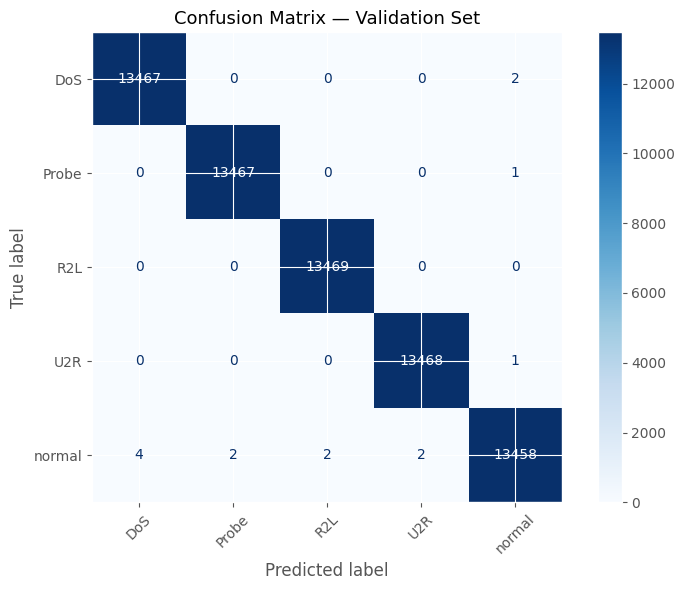

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix — Validation Set", fontsize=13)
plt.tight_layout()
plt.show()

## Per-Class ROC Curves (One-vs-Rest)

ROC AUC shows how well the model separates each class from all others. AUC = 1.0 is perfect; AUC = 0.5 is random.

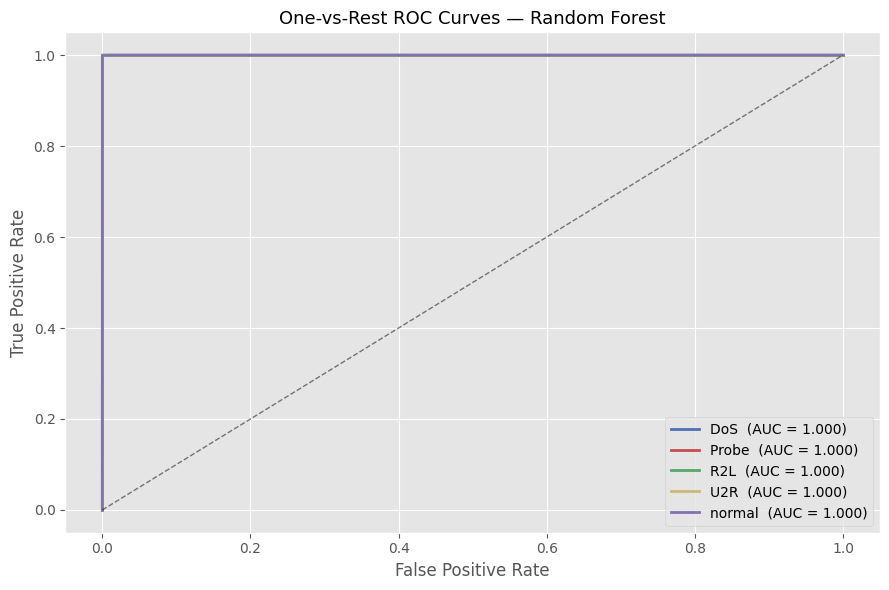

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes    = model.classes_
y_val_bin  = label_binarize(y_val, classes=classes)
y_prob     = model.predict_proba(X_val)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = ['#4C72B0','#C44E52','#55A868','#CCB974','#8172B2']

for i, (cls, col) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves — Random Forest', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Precision–Recall Curves

For imbalanced datasets, Precision-Recall curves are more informative than ROC. High area under the curve (AUPRC) means the model is accurate even for rare classes like U2R.

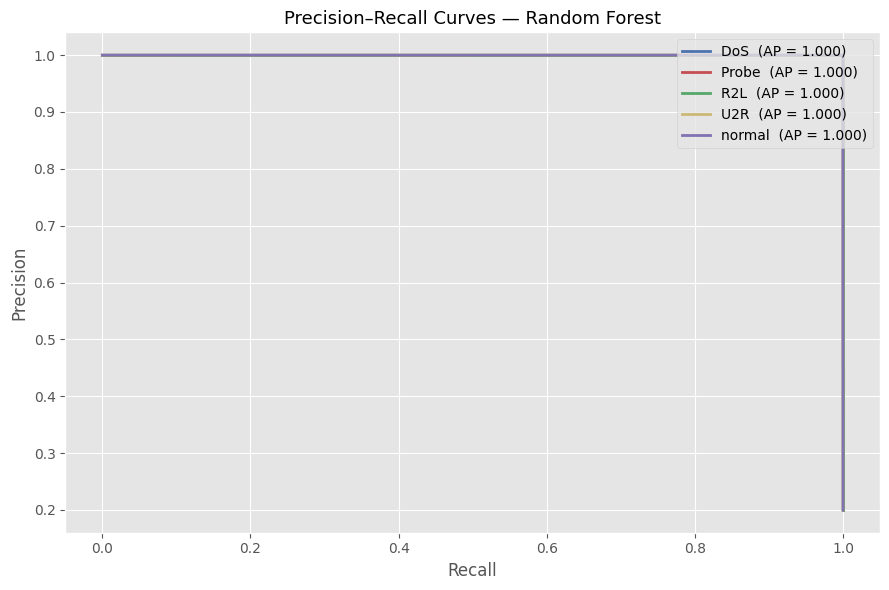

In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 6))

for i, (cls, col) in enumerate(zip(classes, colors)):
    prec, rec, _ = precision_recall_curve(y_val_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_prob[:, i])
    ax.plot(rec, prec, color=col, lw=2, label=f'{cls}  (AP = {ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curves — Random Forest', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## Feature Importance

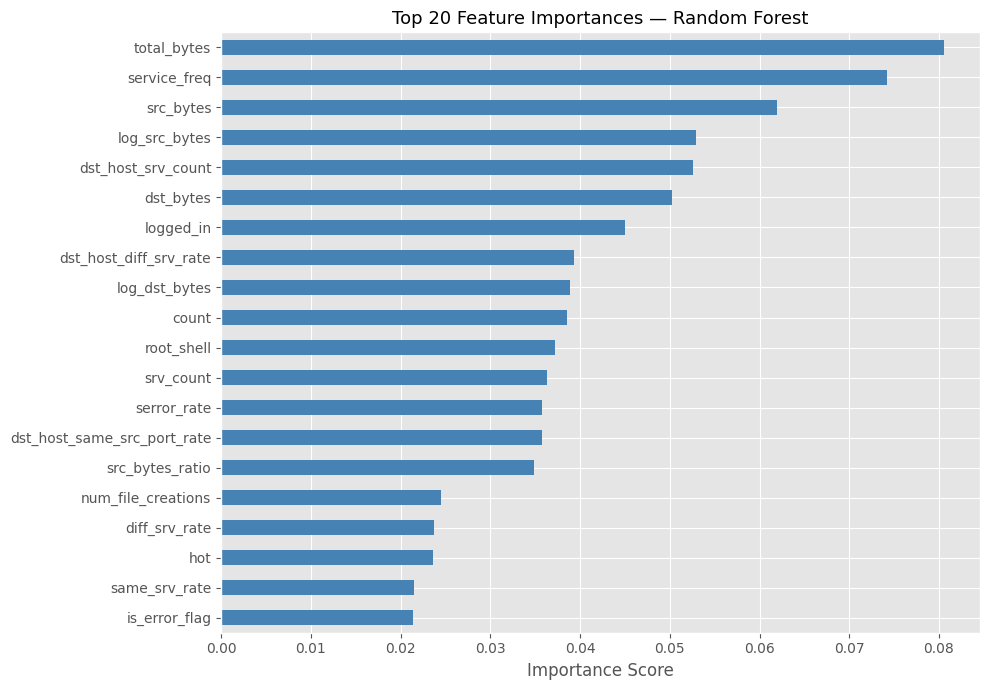

Top 10 most important features:
total_bytes               0.080543
service_freq              0.074156
src_bytes                 0.061998
log_src_bytes             0.052960
dst_host_srv_count        0.052541
dst_bytes                 0.050279
logged_in                 0.045005
dst_host_diff_srv_rate    0.039358
log_dst_bytes             0.038862
count                     0.038602


In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top_20.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Feature Importances — Random Forest", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(top_20.head(10).to_string())

## Anomaly Scoring with Isolation Forest

On top of the 5-class classifier, we add an anomaly *score* from Isolation Forest.  
More negative score = more anomalous. This is surfaced on the SentinelNet dashboard.

## SHAP Analysis

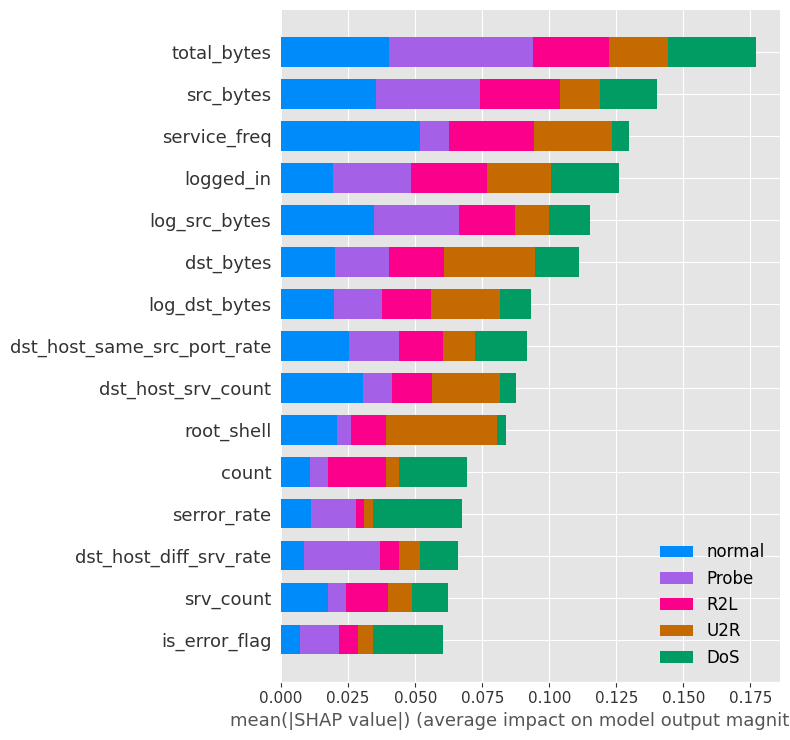

SHAP summary plot rendered above.


In [11]:
try:
    import shap
    shap.initjs()

    # Use a small sample for speed
    sample_idx = X_val.sample(n=min(500, len(X_val)), random_state=SEED).index
    X_shap     = X_val.loc[sample_idx]

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # Summary plot — top features across ALL classes
    plt.figure()
    shap.summary_plot(
        shap_values, X_shap,
        class_names=model.classes_,
        plot_type='bar',
        max_display=15,
        show=True
    )
    print('SHAP summary plot rendered above.')
except ImportError:
    print('SHAP not installed — skipping.')
    print('Install with: pip install shap')
    print()
    # Fallback: show the sklearn feature importances we already have
    top_10 = importances.sort_values(ascending=False).head(10)
    print('Top 10 features by Random Forest importance (proxy for SHAP):')
    print(top_10)

In [ ]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=SEED
)
iso_model.fit(X_train)

# Score validation set
val_df = X_val.copy()
val_df["anomaly_label"] = iso_model.predict(X_val)      # 1 = normal, -1 = anomaly
val_df["anomaly_score"] = iso_model.decision_function(X_val)  # lower = more anomalous
val_df["true_class"]    = y_val.values

n_flagged = (val_df["anomaly_label"] == -1).sum()
print(f"Isolation Forest flagged {n_flagged:,} records as anomalous")
print(f"  ({n_flagged / len(val_df) * 100:.2f}% of validation set)")

print("\nTop 10 most anomalous records:")
val_df.sort_values("anomaly_score").head(10)[["true_class", "anomaly_score", "anomaly_label"]]

In [ ]:
# Anomaly score distribution by true class
plt.figure(figsize=(10, 5))
for cls in val_df["true_class"].unique():
    scores = val_df[val_df["true_class"] == cls]["anomaly_score"]
    sns.kdeplot(scores, label=cls, fill=False)
plt.axvline(0, color="black", linestyle="--", alpha=0.5, label="Decision boundary")
plt.title("Isolation Forest Anomaly Score by Attack Class", fontsize=13)
plt.xlabel("Anomaly Score (lower = more anomalous)")
plt.legend()
plt.tight_layout()
plt.show()

## Save Models

In [ ]:
joblib.dump(model,         os.path.join(MODELS_DIR, "model.pkl"))
joblib.dump(iso_model,     os.path.join(MODELS_DIR, "iso_model.pkl"))
joblib.dump(list(X.columns), os.path.join(MODELS_DIR, "feature_columns.pkl"))

print("Models saved:")
for fname in os.listdir(MODELS_DIR):
    path = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(path) / (1024 * 1024)
    print(f"   {fname}  ({size:.2f} MB)")

## Check

In [ ]:
# Load back
loaded_model    = joblib.load(os.path.join(MODELS_DIR, "model.pkl"))
loaded_iso      = joblib.load(os.path.join(MODELS_DIR, "iso_model.pkl"))
feature_columns = joblib.load(os.path.join(MODELS_DIR, "feature_columns.pkl"))

# Take one validation row and predict
sample = X_val.iloc[[0]][feature_columns]
pred_class  = loaded_model.predict(sample)[0]
pred_prob   = loaded_model.predict_proba(sample).max()

print(f"True class      : {y_val.iloc[0]}")
print(f"Predicted class : {pred_class}")
print(f"Confidence      : {pred_prob:.4f}")

### Model Summary

| Item | Detail |
|------|--------|
| Algorithm | Random Forest (300 trees) |
| Classes | normal, DoS, Probe, R2L, U2R |
| Class balancing | SMOTE |
| Anomaly detection | Isolation Forest (contamination=1%) |